In [1]:
#import statements
import numpy as np
import rebound
import matplotlib.pyplot as plt
from celmech import Poincare, PoincareHamiltonian
from celmech.disturbing_function import laplace_b, df_coefficient_Ctilde, evaluate_df_coefficient_dict
import symengine as se
from tqdm import tqdm
import heyoka as hy
from scipy import signal
import sympy as sp
import time

from hk_integrator import hk_integrate, ft, pomega_ft, get_pomega, get_ecc

In [2]:
#constants
m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

## Looking at the PHAM

In [6]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=2) 

pham.df

<IPython.core.display.Math object>

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634826153e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:03<00:00, 25568.37it/s]


-8.880166634826277e-05
Energy Percent Change: 1.4040643037806456e-12 %
*** Simulation Complete ***
Time elapsed  = 3.914178543000162 seconds


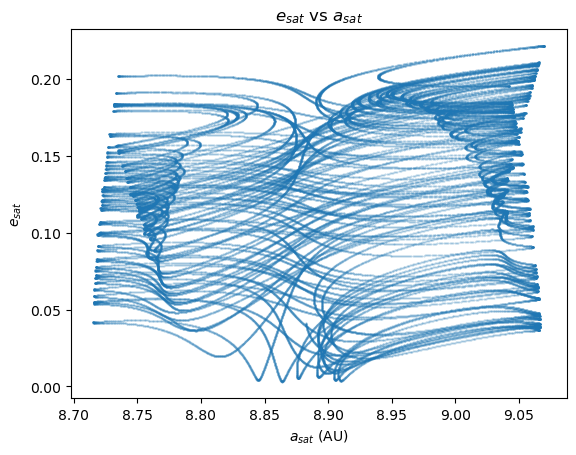

In [27]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_cosine_term([4,-2,-1,-1,0,0],indexIn = 1, indexOut = 2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=1) 
pham.add_secular_terms(indexIn = 1, indexOut = 2, max_order = 2)

times, pomega_sat, e_sat, a_sat, a_jup = hk_integrate(pham, 1e5, 1e5)

plt.title(r'$e_{sat}$ vs $a_{sat}$')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'$a_{sat}$ (AU)')
plt.scatter(a_sat, e_sat, s = 0.25, alpha = 0.25)
plt.show()

In [28]:
pham.df

<IPython.core.display.Math object>

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634826153e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:04<00:00, 24741.29it/s]


-8.880166634826277e-05
Energy Percent Change: 1.4040643037806456e-12 %
*** Simulation Complete ***
Time elapsed  = 4.044105754999691 seconds


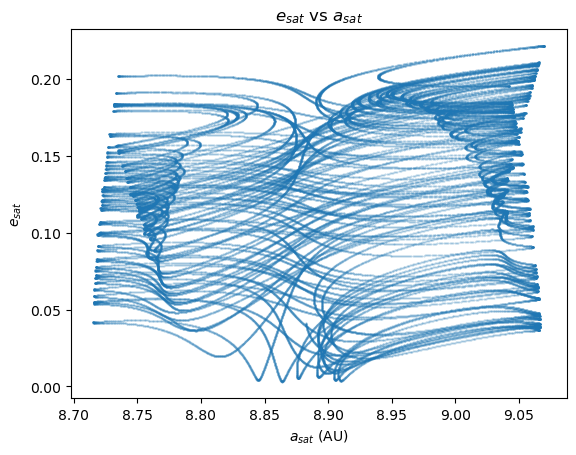

In [18]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_cosine_term([4,-2,-1,-1,0,0],indexIn = 1, indexOut = 2)
pham.add_cosine_term([2,-1,0,-1,0,0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([2,-1,-1,0,0,0], indexIn = 1, indexOut = 2)
#pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=1) 
pham.add_secular_terms(indexIn = 1, indexOut = 2, max_order = 2)

times, pomega_sat, pomega_jup, e_sat, a_sat, a_jup, lam_sat, lam_jup = hk_integrate(pham, 1e5, 1e5)

plt.title(r'$e_{sat}$ vs $a_{sat}$')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'$a_{sat}$ (AU)')
plt.scatter(a_sat, e_sat, s = 0.25, alpha = 0.25)
plt.show()

In [19]:
pham.df

<IPython.core.display.Math object>

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634826153e-05
*** Starting Simulation ***


100%|██████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:39<00:00, 25088.84it/s]


-8.880166634824644e-05
Energy Percent Change: 1.698612576204194e-11 %
*** Simulation Complete ***
Time elapsed  = 39.861503590999746 seconds


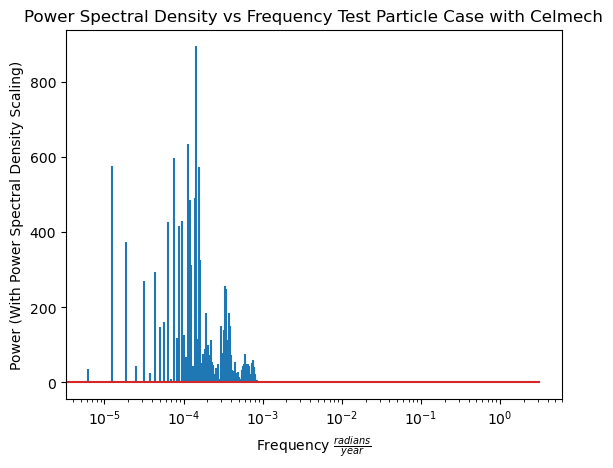

In [21]:
## fourrier transform tests
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_cosine_term([4,-2,-1,-1,0,0],indexIn = 1, indexOut = 2)
pham.add_cosine_term([2,-1,0,-1,0,0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([2,-1,-1,0,0,0], indexIn = 1, indexOut = 2)
#pham.add_MMR_terms(2,1, indexIn = 1, indexOut = 2, max_order = 2)
pham.add_secular_terms(indexIn = 1, indexOut = 2, max_order = 2)

times, pomega_sat, pomega_jup, e_sat, a_sat, a_jup, lam_sat, lam_j = hk_integrate(pham, 1e6, 1e6)


f,pxx = pomega_ft(times, pomega_sat, e_sat)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case with Celmech')
plt.show()

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634816146e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:09<00:00, 10477.17it/s]


-8.880166634815167e-05
Energy Percent Change: 1.1018852470986615e-11 %
*** Simulation Complete ***
Time elapsed  = 9.550275829999919 seconds


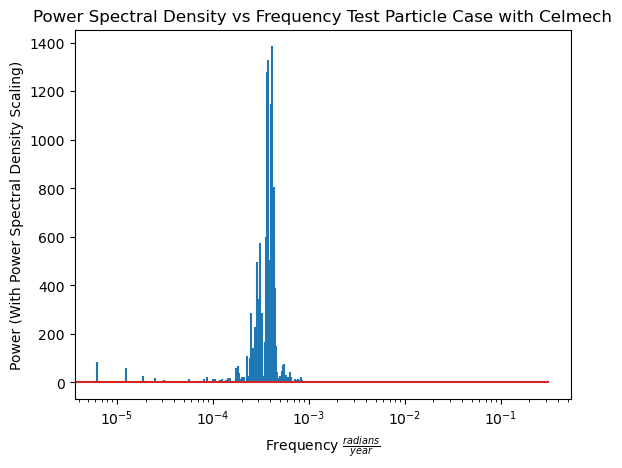

In [10]:
## fourrier transform tests
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
#pham.add_cosine_term([4,-2,-1,-1,0,0],indexIn = 1, indexOut = 2)
#pham.add_cosine_term([4,-2,0,-2,0,0], indexIn = 1, indexOut = 2)
#pham.add_cosine_term([4,-2,-2,0,0,0], indexIn = 1, indexOut = 2)
pham.add_MMR_terms(2,1, indexIn = 1, indexOut = 2, max_order = 2)
pham.add_secular_terms(indexIn = 1, indexOut = 2, max_order = 2)

times, pomega_sat, pomega_jup, e_sat, a_sat, a_jup, lam_sat, lam_j = hk_integrate(pham, 1e6, 1e5)


f,pxx = pomega_ft(times, pomega_sat, e_sat)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case with Celmech')
plt.show()

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634823682e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:06<00:00, 16161.53it/s]


-8.880166634822881e-05
Energy Percent Change: 9.019586994941222e-12 %
*** Simulation Complete ***
Time elapsed  = 6.189981929000169 seconds


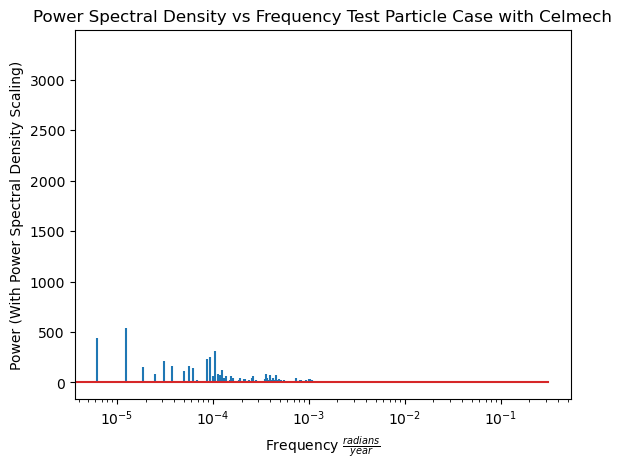

In [34]:
## fourrier transform tests
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_cosine_term([4,-2,-1,-1,0,0,], indexIn = 1, indexOut = 2)
pham.add_cosine_term([4,-2,-2,0,0,0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([4, -2, 0, -2, 0, 0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([2,-1,0,-1,0,0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([2,-1,-1,0,0,0], indexIn = 1, indexOut = 2)
#pham.add_MMR_terms(2,1, indexIn = 1, indexOut = 2, max_order = 2)
pham.add_secular_terms(indexIn = 1, indexOut = 2, max_order = 2)

times, pomega_sat, pomega_jup, e_sat, a_sat, a_jup, lam_sat, lam_j = hk_integrate(pham, 1e6, 1e5)


f,pxx = pomega_ft(times, pomega_sat, e_sat)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency Test Particle Case with Celmech')
plt.show()

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634823682e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:04<00:00, 23976.24it/s]


-8.880166634823617e-05
Energy Percent Change: 7.325552889292363e-13 %
*** Simulation Complete ***
Time elapsed  = 4.173702527000387 seconds


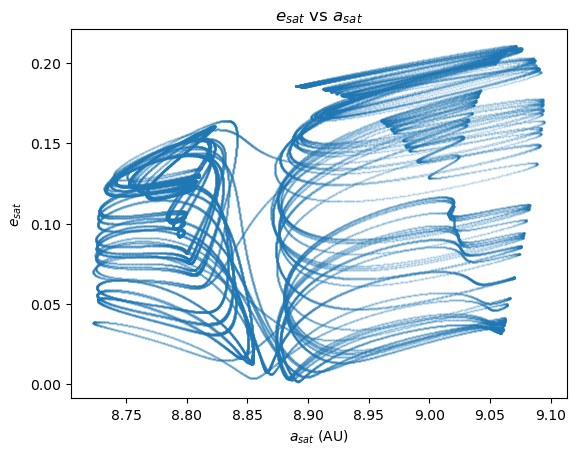

In [33]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=2) 
pham.add_secular_terms(indexIn = 1, indexOut = 2, max_order = 2)

times, pomega_sat, pomega_jup, e_sat, a_sat, a_jup, lam_sat, lam_jup = hk_integrate(pham, 1e5, 1e5)

plt.title(r'$e_{sat}$ vs $a_{sat}$')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'$a_{sat}$ (AU)')
plt.scatter(a_sat, e_sat, s = 0.25, alpha = 0.25)
plt.show()

In [23]:
pham.df

<IPython.core.display.Math object>

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634829491e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:04<00:00, 24407.92it/s]


-8.880166634829296e-05
Energy Percent Change: 2.1976658667862717e-12 %
*** Simulation Complete ***
Time elapsed  = 4.099884392999229 seconds


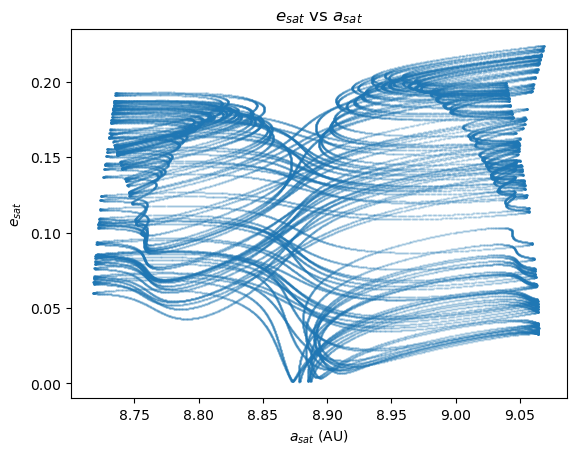

In [35]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_cosine_term([4,-2,-1,-1,0,0,], indexIn = 1, indexOut = 2)
pham.add_cosine_term([4,-2,-2,0,0,0], indexIn = 1, indexOut = 2)
#pham.add_cosine_term([4, -2, 0, -2, 0, 0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([2,-1,0,-1,0,0], indexIn = 1, indexOut = 2)
pham.add_cosine_term([2,-1,-1,0,0,0], indexIn = 1, indexOut = 2)
pham.add_secular_terms(indexIn = 1, indexOut = 2, max_order = 2)

times, pomega_sat, pomega_jup, e_sat, a_sat, a_jup, lam_sat, lam_jup = hk_integrate(pham, 1e5, 1e5)

plt.title(r'$e_{sat}$ vs $a_{sat}$')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'$a_{sat}$ (AU)')
plt.scatter(a_sat, e_sat, s = 0.25, alpha = 0.25)
plt.show()